In [ ]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [11]:
#считывание данных из файла
insurance_df = pd.read_csv('/content/drive/MyDrive/insurance.csv')
#вывод переменной insurance_df
insurance_df.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [12]:
#считывание данных из файла
insurance_df1 = pd.read_csv ('insurance.csv')
#вывод переменной insurance_df1
insurance_df1.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [16]:
print("--- Информация о типах данных ---")
# Проверяем типы столбцов (int, float, object/category)
insurance_df.info()

print("\n--- Проверка на пропущенные значения ---")
# Подсчитываем количество пропусков (NaN) в каждом столбце
print(insurance_df.isnull().sum())

--- Информация о типах данных ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Проверка на пропущенные значения ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [17]:
# 1. Преобразование бинарных категориальных признаков в числа (0 и 1)
insurance_df['sex'] = insurance_df['sex'].map({'female': 0, 'male': 1})
insurance_df['smoker'] = insurance_df['smoker'].map({'no': 0, 'yes': 1})

# 2. Преобразование многоклассового признака 'region' (One-Hot Encoding)
# Это создаст новые числовые столбцы для каждого региона, удаляя первый (drop_first=True) во избежание мультиколлинеарности
insurance_df = pd.get_dummies(insurance_df, columns=['region'], drop_first=True)

# Проверяем результат предобработки
print("\n--- Данные после преобразования категорий ---")
display(insurance_df.head(3))


--- Данные после преобразования категорий ---


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.90,0,1,16884.9240,False,False,True
1,18,1,33.77,1,0,1725.5523,False,True,False
2,28,1,33.00,3,0,4449.4620,False,True,False


/tmp/ipykernel_1632/1636132013.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=insurance_df1, ax=axes[1], palette='Set2')


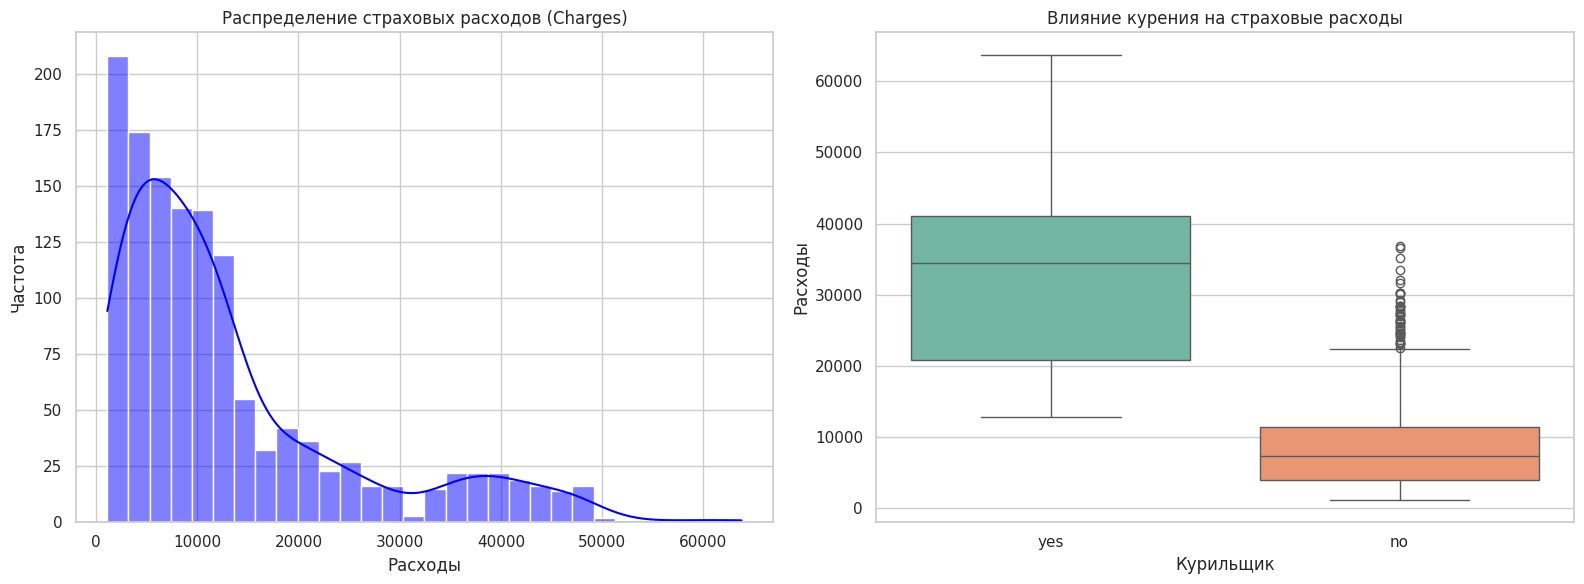

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Установим стиль для графиков
sns.set_theme(style="whitegrid")

# Создадим фигуру с несколькими графиками
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Распределение расходов (Charges)
sns.histplot(insurance_df['charges'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Распределение страховых расходов (Charges)')
axes[0].set_xlabel('Расходы')
axes[0].set_ylabel('Частота')

# 2. Влияние курения на расходы (используем исходный датафрейм для понятных подписей)
sns.boxplot(x='smoker', y='charges', data=insurance_df1, ax=axes[1], palette='Set2')
axes[1].set_title('Влияние курения на страховые расходы')
axes[1].set_xlabel('Курильщик')
axes[1].set_ylabel('Расходы')

plt.tight_layout()
plt.show()

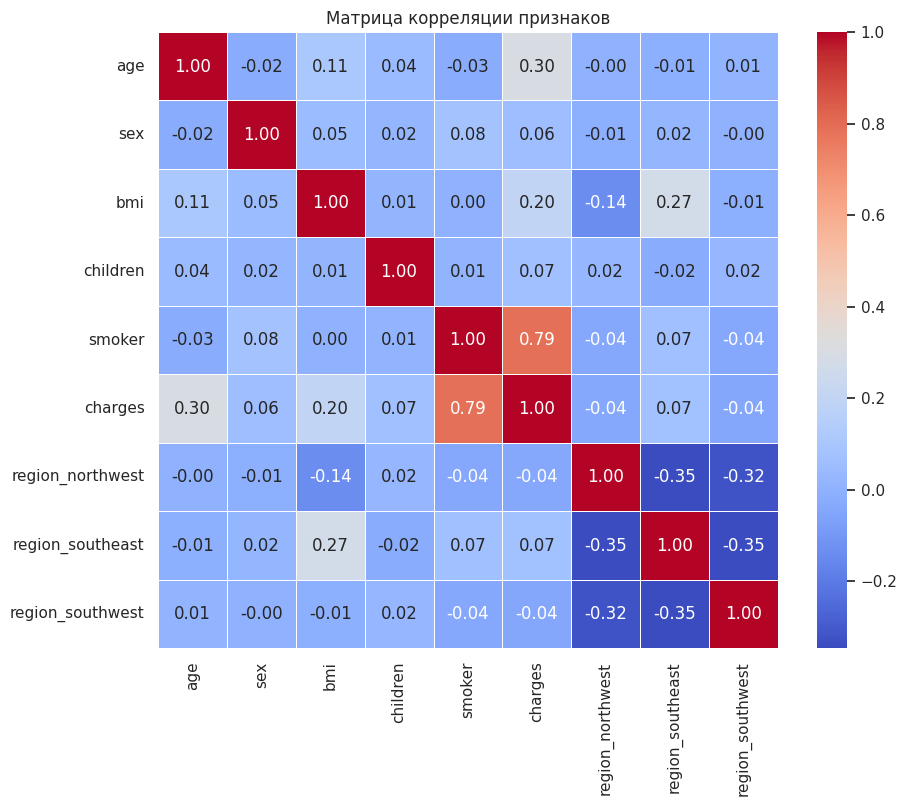

In [22]:
# 3. Тепловая карта корреляции
plt.figure(figsize=(10, 8))
correlation_matrix = insurance_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции признаков')
plt.show()